# 02 · Run a simulation & inspect every output

A setup directory is **all `Runner` needs**. Point it at one, call `.run()`, and you get
back a single nested `run_log` dict holding every per-tick snapshot of the world.

This notebook runs `setups/three_node_chain` once, then **dissects every output surface**:

1. the raw `run_log` structure,
2. the four tidy *inspect* helpers (`node_timeseries_df`, `node_equity`,
   `global_timeseries_df`, `per_product_df`),
3. the on-disk artifacts the `DataExporter` writes (parquet + JSON + a PNG report),
4. a quick multi-supplier view using `setups/two_factories_two_shops`.

> New paradigm note: the old `World` / `world_to_graph` flow is gone — a setup directory
> *is* the scenario, and `run_log` is a plain dict you can poke at directly.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths like
# `setups/three_node_chain` resolve no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · Load a setup and run it

`setups/three_node_chain` is the minimal example: one factory → one shop → one demand
sink, 2 products, 30 ticks. `Runner(scenario).run()` plays it forward and returns the
`run_log`.

In [2]:
from src.sim.setup_io import load_setup
from src.sim.runner import Runner

scenario = load_setup("setups/three_node_chain")
run_log = Runner(scenario).run()

print("nodes:", [(ni.node.id, type(ni.node).__name__) for ni in scenario.nodes])
print("ran", run_log["n_steps"], "ticks")

nodes: [('factory-1', 'FactoryNode'), ('shop-1', 'IntermediateNode'), ('sink-1', 'DemandSinkNode')]
ran 30 ticks


## 2 · Anatomy of the `run_log`

The `run_log` is a dict with three top-level keys:

| key | what it holds |
|---|---|
| `n_steps` | number of ticks simulated |
| `ticks`   | list of per-tick snapshots (one dict per tick) |
| `global`  | the shared world series — time, market supply/demand, events |

Each entry in `ticks` carries the same four per-node dicts.

In [3]:
print("top-level keys:", list(run_log.keys()))
print("n_steps        :", run_log["n_steps"])
print("len(ticks)     :", len(run_log["ticks"]))
print("one tick's keys:", list(run_log["ticks"][0].keys()))
print("global keys    :", list(run_log["global"].keys()))

top-level keys: ['n_steps', 'ticks', 'global']
n_steps        : 30
len(ticks)     : 30
one tick's keys: ['tick', 'node_cash', 'node_inventory', 'node_pending', 'node_orders']
global keys    : ['time', 'market_supply', 'market_demand', 'events']


### One tick, up close

Every tick maps `node_id → value`. `node_cash` is a flat float per node. `node_inventory`,
`node_pending`, and `node_orders` are `{node_id: {product_id: int}}` — except **factory**
nodes, whose inventory is a single fungible `_total` (they make one product to order).

In [4]:
tick0 = run_log["ticks"][0]
print("node_cash      :", tick0["node_cash"])
print("node_inventory :", tick0["node_inventory"])
print("node_pending   :", tick0["node_pending"])
print("node_orders    :", tick0["node_orders"])

node_cash      : {'factory-1': -250.0, 'shop-1': 588.0, 'sink-1': 1112.0}
node_inventory : {'factory-1': {'_total': 150}, 'shop-1': {'P0001': 9}, 'sink-1': {}}
node_pending   : {'factory-1': {}, 'shop-1': {}, 'sink-1': {}}
node_orders    : {'shop-1': {}}


You *can* read these raw dicts, but slicing time-series out of a list-of-dicts by hand
is tedious. That is exactly what the **inspect helpers** do for you.

## 3 · Tidy inspection — the four helpers

`src/sim/inspect.py` ships four pure functions that flatten the `run_log` into tidy
pandas DataFrames. No plotting, no I/O — just rows you can group and chart.

In [5]:
from src.sim.inspect import (
    node_timeseries_df,
    global_timeseries_df,
    per_product_df,
    node_equity,
)

ts = node_timeseries_df(run_log, scenario)
print("node_timeseries_df columns:", list(ts.columns))
ts.head()

node_timeseries_df columns: ['tick', 'node_id', 'node_type', 'region', 'level', 'cash', 'inventory_total', 'pending_total', 'orders_total']


,tick,node_id,node_type,region,level,cash,inventory_total,pending_total,orders_total
0,1,factory-1,FactoryNode,US,None,-250.0,150,0,0
1,1,shop-1,IntermediateNode,US,None,588.0,9,0,0
2,1,sink-1,DemandSinkNode,US,None,1112.0,0,0,0
3,2,factory-1,FactoryNode,US,None,-135.0,127,0,0
4,2,shop-1,IntermediateNode,US,None,295.0,0,73,73


### 3a · Per-node time series

`node_timeseries_df` gives one row per `(tick, node)` with `cash`, `inventory_total`,
`pending_total`, and `orders_total`. We chart each metric as a small multiple, one line
per node.

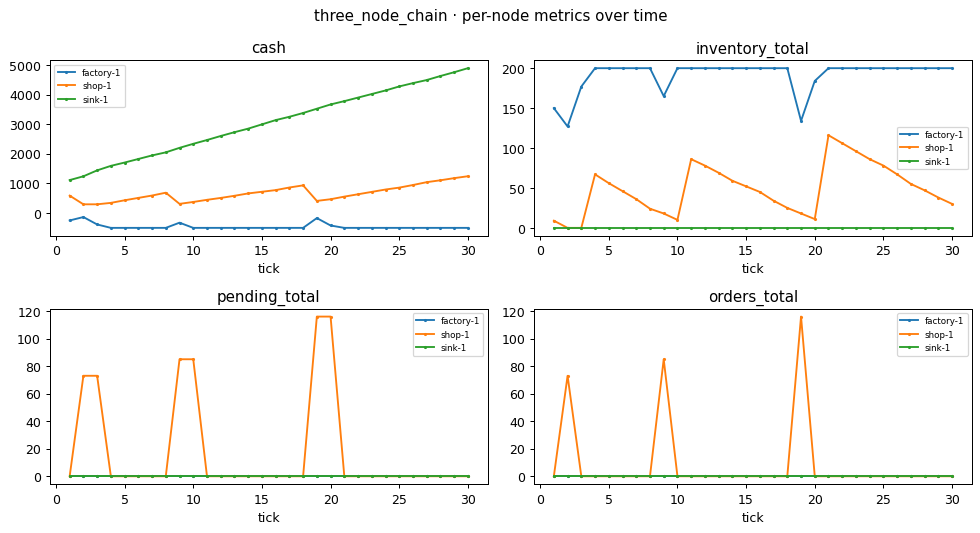

In [6]:
metrics = ["cash", "inventory_total", "pending_total", "orders_total"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

for ax, metric in zip(axes.ravel(), metrics):
    for nid, g in ts.groupby("node_id"):
        ax.plot(g["tick"], g[metric], label=nid, marker=".", ms=3)
    ax.set_title(metric)
    ax.set_xlabel("tick")
    ax.legend(fontsize=7)

fig.suptitle("three_node_chain · per-node metrics over time")
plt.tight_layout()
plt.show()

### 3b · Node equity — where the value sits

`node_equity` decomposes a node's worth into **cash + inventory-at-cost +
outstanding-at-cost** (in-transit units valued at `unit_cost`). The three sum to `equity`.
A stacked area for the shop shows how value sloshes between cash and stock as it buys,
holds, and sells.

node_equity columns: ['tick', 'node_id', 'cash', 'inventory_value', 'outstanding_value', 'equity']


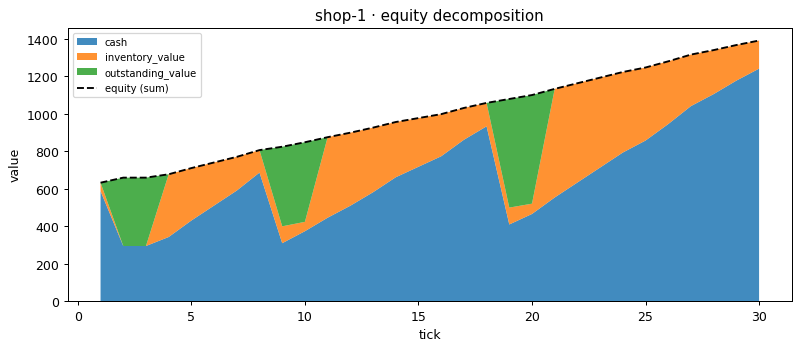

,tick,node_id,cash,inventory_value,outstanding_value,equity
0,1,shop-1,588.0,45.0,0.0,633.0
1,2,shop-1,295.0,0.0,365.0,660.0
2,3,shop-1,295.0,0.0,365.0,660.0
3,4,shop-1,343.0,335.0,0.0,678.0
4,5,shop-1,431.0,280.0,0.0,711.0


In [7]:
eq = node_equity(run_log, scenario, "shop-1")
print("node_equity columns:", list(eq.columns))

fig, ax = plt.subplots(figsize=(9, 4))
parts = ["cash", "inventory_value", "outstanding_value"]
ax.stackplot(eq["tick"], [eq[p] for p in parts], labels=parts, alpha=0.85)
ax.plot(eq["tick"], eq["equity"], color="black", lw=1.5, ls="--", label="equity (sum)")
ax.set_title("shop-1 · equity decomposition")
ax.set_xlabel("tick")
ax.set_ylabel("value")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

eq.head()

### 3c · The shared world — market supply vs demand

`global_timeseries_df` pivots `run_log["global"]` into one column per region for both
supply and demand. With a single region (`US`) here, that is two series.

global_timeseries_df columns: ['tick', 'market_supply_US', 'market_demand_US']


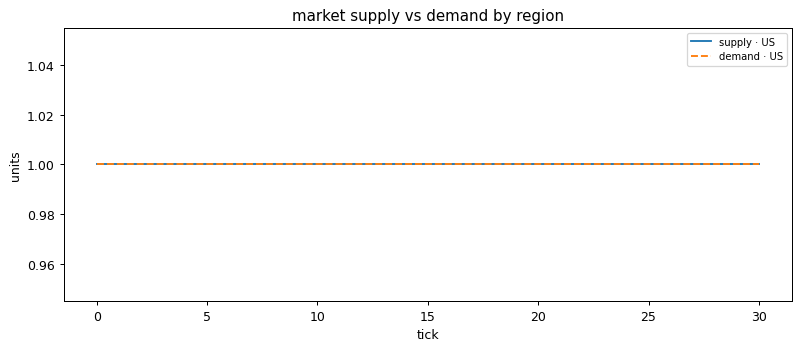

,tick,market_supply_US,market_demand_US
0,0,1.0,1.0
1,1,1.0,1.0
2,2,1.0,1.0
3,3,1.0,1.0
4,4,1.0,1.0


In [8]:
gts = global_timeseries_df(run_log)
print("global_timeseries_df columns:", list(gts.columns))

supply_cols = [c for c in gts.columns if c.startswith("market_supply_")]
demand_cols = [c for c in gts.columns if c.startswith("market_demand_")]
regions = [c.removeprefix("market_supply_") for c in supply_cols]

fig, ax = plt.subplots(figsize=(9, 4))
for region in regions:
    ax.plot(gts["tick"], gts[f"market_supply_{region}"], label=f"supply · {region}")
    ax.plot(gts["tick"], gts[f"market_demand_{region}"], label=f"demand · {region}", ls="--")
ax.set_title("market supply vs demand by region")
ax.set_xlabel("tick")
ax.set_ylabel("units")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

gts.head()

### 3d · Per-product detail for one node

`per_product_df(run_log, scenario, node_id)` breaks a single node down to one row per
`(tick, product)` — inventory, pending, and orders. (Factory `_total` rows are excluded.)
`shop-1` carries two SKUs.

per_product_df columns: ['tick', 'node_id', 'pid', 'inventory', 'pending', 'orders']
products at shop-1: ['P0001']


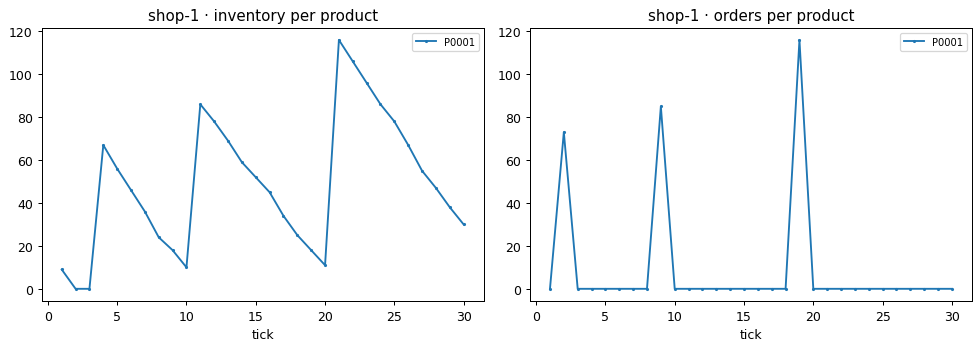

,tick,node_id,pid,inventory,pending,orders
0,1,shop-1,P0001,9,0,0
1,2,shop-1,P0001,0,73,73
2,3,shop-1,P0001,0,73,0
3,4,shop-1,P0001,67,0,0
4,5,shop-1,P0001,56,0,0


In [9]:
pp = per_product_df(run_log, scenario, "shop-1")
print("per_product_df columns:", list(pp.columns))
print("products at shop-1:", sorted(pp["pid"].unique()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for pid, g in pp.groupby("pid"):
    axes[0].plot(g["tick"], g["inventory"], label=pid, marker=".", ms=3)
    axes[1].plot(g["tick"], g["orders"], label=pid, marker=".", ms=3)
axes[0].set_title("shop-1 · inventory per product")
axes[1].set_title("shop-1 · orders per product")
for ax in axes:
    ax.set_xlabel("tick")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pp.head()

## 4 · Export & re-read artifacts

`DataExporter(scenario, run_log)` persists the run to disk. `export_all(folder)` writes a
config JSON, the full run-log JSON, three parquet tables, and a PNG report.

Note: `export_all` writes `stores.parquet` (the node roster, legacy name). The
`nodes.parquet` table comes from a **separate** `save_nodes_parquet(...)` call — so we run
both.

In [10]:
from src.sim.data_exporter import DataExporter

out = "data/notebook_demos/02/run"
ex = DataExporter(scenario, run_log)
ex.export_all(out)
ex.save_nodes_parquet(out)

written = sorted(str(p.relative_to(out)) for p in Path(out).rglob("*") if p.is_file())
print("files written under", out, ":")
for f in written:
    print("  ", f)

files written under data/notebook_demos/02/run :
   config/scenario.json
   data/nodes.parquet
   data/products.parquet
   data/run_log.json
   data/stores.parquet
   data/timeseries.parquet
   reports/overview.png


### Re-read the parquet tables

The parquet files round-trip straight back into pandas. We confirm the actual columns
(don't assume!) and peek at each.

In [11]:
products = pd.read_parquet(f"{out}/data/products.parquet")
timeseries = pd.read_parquet(f"{out}/data/timeseries.parquet")
nodes = pd.read_parquet(f"{out}/data/nodes.parquet")

print("products.parquet columns  :", list(products.columns))
print("timeseries.parquet columns:", list(timeseries.columns))
print("nodes.parquet columns     :", list(nodes.columns))

products.parquet columns  : ['product_id', 'name', 'category', 'base_price', 'unit_cost', 'seasonality', 'freshness_alpha', 'freshness_decay', 'init_stock_share']
timeseries.parquet columns: ['simulation_step', 'simulation_date', 'store_id', 'product_id', 'inventory', 'demand', 'sales', 'order_quantity', 'outstanding_orders', 'promotion_status', 'active_status', 'price', 'revenue', 'total_cost', 'holding_cost', 'profit']
nodes.parquet columns     : ['node_id', 'node_type', 'region', 'init_seed', 'policy_type']


In [12]:
display(products.head())
display(timeseries.head())
display(nodes.head())

,product_id,name,category,base_price,unit_cost,seasonality,freshness_alpha,freshness_decay,init_stock_share
0,P0001,Widget A,widgets,12.5,5.0,peak,None,None,None


,simulation_step,simulation_date,store_id,product_id,inventory,demand,sales,order_quantity,outstanding_orders,promotion_status,active_status,price,revenue,total_cost,holding_cost,profit
0,1,2024-01-02,shop-1,P0001,9,None,None,None,None,None,None,None,None,None,None,None
1,2,2024-01-03,shop-1,P0001,0,None,None,None,None,None,None,None,None,None,None,None
2,3,2024-01-04,shop-1,P0001,0,None,None,None,None,None,None,None,None,None,None,None
3,4,2024-01-05,shop-1,P0001,67,None,None,None,None,None,None,None,None,None,None,None
4,5,2024-01-06,shop-1,P0001,56,None,None,None,None,None,None,None,None,None,None,None


,node_id,node_type,region,init_seed,policy_type
0,factory-1,FactoryNode,US,3234706689,StaticFactoryPolicy
1,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
2,sink-1,DemandSinkNode,US,3754311622,DefaultDemandSinkPolicy


### Display the exported PNG report

`export_all` also renders a regional supply/demand chart to `reports/overview.png`. We
embed the written file inline.

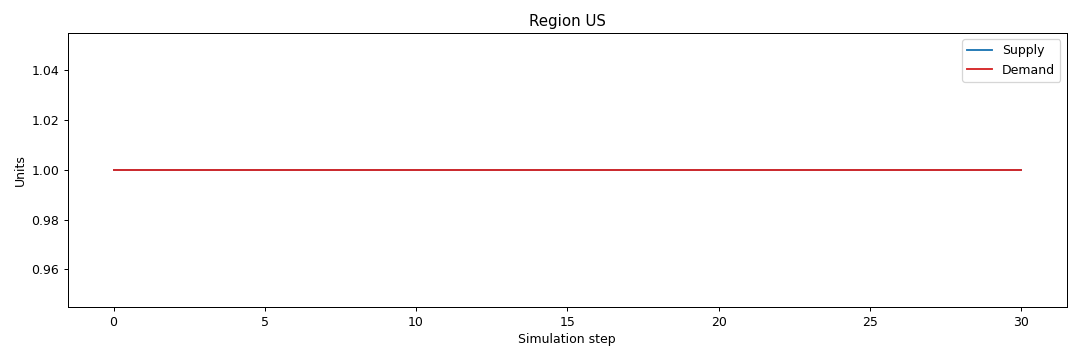

In [13]:
from IPython.display import Image

Image(filename=f"{out}/reports/overview.png")

## 5 · Multi-supplier view

`setups/two_factories_two_shops` wires **two factories into each shop** (`f-lo` with a long
lead time, `f-hi` with a short one). A shop chooses which supplier to order from per tick.

The `run_log`'s `node_pending` is keyed only by product, so it **aggregates in-transit units
across both suppliers** — you see *how much* is on the way, not *from whom*. `per_product_df`
surfaces that combined pending series.

In [14]:
multi = load_setup("setups/two_factories_two_shops")
multi_log = Runner(multi).run()

print("nodes:", [(ni.node.id, type(ni.node).__name__) for ni in multi.nodes])
display(multi.edges_df())

nodes: [('f-lo', 'FactoryNode'), ('f-hi', 'FactoryNode'), ('shop-1', 'IntermediateNode'), ('shop-2', 'IntermediateNode'), ('sink-1', 'DemandSinkNode'), ('sink-2', 'DemandSinkNode')]


,supplier_id,buyer_id,default_lead_time
0,f-lo,shop-1,4
1,f-hi,shop-1,2
2,f-lo,shop-2,4
3,f-hi,shop-2,2
4,shop-1,sink-1,1
5,shop-2,sink-2,1


shop-1 supplies from: ['f-lo', 'f-hi']


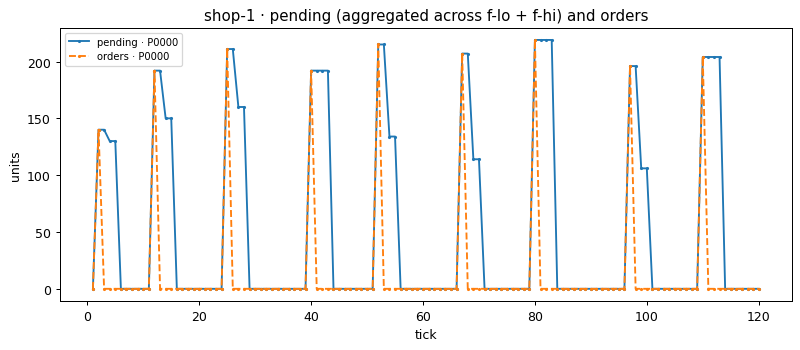

,tick,node_id,pid,inventory,pending,orders
0,1,shop-1,P0000,13,0,0
1,2,shop-1,P0000,3,140,140
2,3,shop-1,P0000,0,140,0
3,4,shop-1,P0000,0,130,0
4,5,shop-1,P0000,0,130,0


In [15]:
shop_pp = per_product_df(multi_log, multi, "shop-1")
print("shop-1 supplies from:",
      multi.edges_df().query("buyer_id == 'shop-1'")["supplier_id"].tolist())

fig, ax = plt.subplots(figsize=(9, 4))
for pid, g in shop_pp.groupby("pid"):
    ax.plot(g["tick"], g["pending"], label=f"pending · {pid}", marker=".", ms=3)
    ax.plot(g["tick"], g["orders"], label=f"orders · {pid}", ls="--", marker=".", ms=3)
ax.set_title("shop-1 · pending (aggregated across f-lo + f-hi) and orders")
ax.set_xlabel("tick")
ax.set_ylabel("units")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

shop_pp.head()

The `pending` column rises as orders go out and falls as deliveries land — but because
both `f-lo` and `f-hi` feed the same product slot, the curve is their **sum**. To attribute
in-transit stock to a specific supplier you'd inspect the node's order book directly; the
run-log aggregate is the right granularity for a quick health check.

## Where to next

| notebook | topic |
|---|---|
| **03** | topology gallery — build, draw, run & compare several DAG shapes |
| **04** | compare the four textbook policies under Common Random Numbers |
| **05** | tune a policy with Optuna |
| **06** | train a PPO agent and evaluate it against the textbook baseline |